<a href="https://colab.research.google.com/github/btm89/BTE-320/blob/main/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
df = pd.read_csv('travel-times.csv')

In [17]:
print(df.shape)

(205, 13)


In [18]:
df.head(15)

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
0,1/6/2012,16:37,Friday,Home,51.29,127.4,78.3,84.8,NaN,39.3,36.3,No,NaN
1,1/6/2012,08:20,Friday,GSK,51.63,130.3,81.8,88.9,NaN,37.9,34.9,No,NaN
2,1/4/2012,16:17,Wednesday,Home,51.27,127.4,82.0,85.8,NaN,37.5,35.9,No,NaN
3,1/4/2012,07:53,Wednesday,GSK,49.17,132.3,74.2,82.9,NaN,39.8,35.6,No,NaN
4,1/3/2012,18:57,Tuesday,Home,51.15,136.2,83.4,88.1,NaN,36.8,34.8,No,NaN
5,1/3/2012,07:57,Tuesday,GSK,51.80,135.8,84.5,88.8,NaN,36.8,35.0,No,NaN
6,1/2/2012,17:31,Monday,Home,51.37,123.2,82.9,87.3,-,37.2,35.3,No,NaN
7,1/2/2012,07:34,Monday,GSK,49.01,128.3,77.5,85.9,-,37.9,34.3,No,NaN
8,12/23/2011,08:01,Friday,GSK,52.91,130.3,80.9,88.3,8.89,39.3,36.0,No,NaN
9,12/22/2011,17:19,Thursday,Home,51.17,122.3,70.6,78.1,8.89,43.5,39.3,No,NaN


In [37]:
df.info()
print(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            205 non-null    datetime64[ns]
 1   StartTime       205 non-null    object        
 2   DayOfWeek       205 non-null    object        
 3   GoingTo         205 non-null    object        
 4   Distance        205 non-null    float64       
 5   MaxSpeed        205 non-null    float64       
 6   AvgSpeed        205 non-null    float64       
 7   AvgMovingSpeed  205 non-null    float64       
 8   FuelEconomy     188 non-null    object        
 9   TotalTime       205 non-null    float64       
 10  MovingTime      205 non-null    float64       
 11  Take407All      205 non-null    object        
 12  Comments        24 non-null     object        
dtypes: datetime64[ns](1), float64(6), object(6)
memory usage: 20.9+ KB
FuelEconomy     17
Comments       181
dtype

In [24]:
df = df.drop_duplicates(keep='last')

In [25]:
df.isnull().sum()

,0
Date,0
StartTime,0
DayOfWeek,0
GoingTo,0
Distance,0
MaxSpeed,0
AvgSpeed,0
AvgMovingSpeed,0
FuelEconomy,17
TotalTime,0


In [27]:
df1 = df.copy()
df2 = df.copy()

In [28]:
df1 = df1.dropna()

In [29]:
df2 = df2.dropna(axis=1)

In [30]:
df.describe()

df.corr(numeric_only=True)

,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,TotalTime,MovingTime
Distance,1.000000,0.145091,-0.006445,0.011874,0.197207,0.197044
MaxSpeed,0.145091,1.000000,0.253869,0.257823,-0.198775,-0.222574
AvgSpeed,-0.006445,0.253869,1.000000,0.872143,-0.877806,-0.835814
AvgMovingSpeed,0.011874,0.257823,0.872143,1.000000,-0.856986,-0.944433
TotalTime,0.197207,-0.198775,-0.877806,-0.856986,1.000000,0.920935
MovingTime,0.197044,-0.222574,-0.835814,-0.944433,0.920935,1.000000


In [31]:
df.iloc[10:14]

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
10,12/22/2011,08:16,Thursday,GSK,49.15,129.4,74.0,81.4,8.89,39.8,36.2,No,NaN
11,12/21/2011,07:45,Wednesday,GSK,51.77,124.8,71.7,78.9,8.89,43.3,39.4,No,NaN
12,12/20/2011,16:05,Tuesday,Home,51.45,130.1,75.2,82.7,8.89,41.1,37.3,No,NaN
13,12/20/2011,06:04,Tuesday,GSK,49.01,119.0,77.4,82.0,8.89,38.0,35.9,No,NaN


In [32]:
df['Date'] = pd.to_datetime(df['Date'])

subset = df[
    (df['Date'] == '2011-11-23') |
    (df['Date'] == '2012-01-06')
]

subset

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
0,2012-01-06,16:37,Friday,Home,51.29,127.4,78.3,84.8,NaN,39.3,36.3,No,NaN
1,2012-01-06,08:20,Friday,GSK,51.63,130.3,81.8,88.9,NaN,37.9,34.9,No,NaN
44,2011-11-23,16:17,Wednesday,Home,60.32,129.4,68.9,74.6,9.3,52.5,48.5,No,NaN
45,2011-11-23,07:22,Wednesday,GSK,51.60,126.4,67.3,73.6,9.3,46.0,42.1,No,NaN


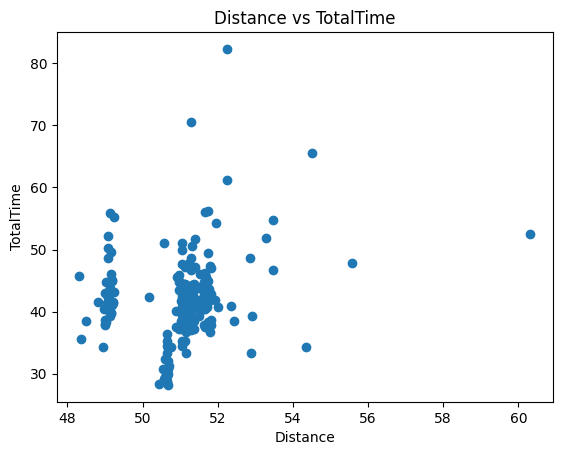

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df['Distance'], df['TotalTime'])
plt.xlabel('Distance')
plt.ylabel('TotalTime')
plt.title('Distance vs TotalTime')
plt.show()

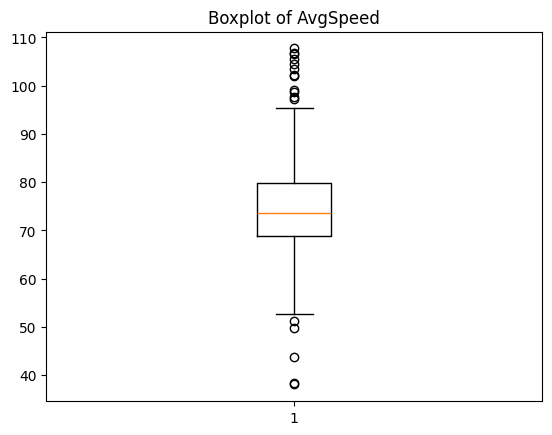

In [35]:
plt.boxplot(df['AvgSpeed'])
plt.title('Boxplot of AvgSpeed')
plt.show()

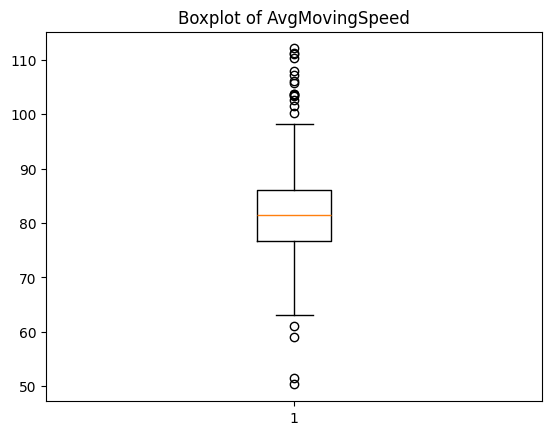

In [36]:
plt.boxplot(df['AvgMovingSpeed'])
plt.title('Boxplot of AvgMovingSpeed')
plt.show()